# Exploratory Data Analysis — MRL Eye Dataset

This notebook performs EDA on the **MRL Eye Dataset** used for driver drowsiness detection.

**Dataset:** MRL Eye Dataset (CC0 Public Domain)  
**Task:** Binary classification — `0 = Closed eye (drowsy)` | `1 = Open eye (alert)`  
**Raw structure:**
```
datasets/raw/mrleye/
├── closed/   ← closed-eye images
└── open/     ← open-eye images
```
**Processed data:** NumPy arrays saved in `datasets/processed/mrl_eye/`


In [3]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from pathlib import Path
from collections import Counter

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))

sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Paths
RAW_DIR       = Path('../datasets/raw/mrleye')
PROCESSED_DIR = Path('../datasets/processed/mrl_eye')

CLASS_NAMES = {0: 'Closed (Drowsy)', 1: 'Open (Alert)'}
COLORS      = {0: '#e74c3c', 1: '#2ecc71'}

print("Paths set up successfully.")
print(f"Raw data     : {RAW_DIR}")
print(f"Processed data: {PROCESSED_DIR}")


Paths set up successfully.
Raw data     : ..\datasets\raw\mrleye
Processed data: ..\datasets\processed\mrl_eye


In [5]:
VALID_EXTS = {'.png', '.jpg', '.jpeg', '.bmp'}

def count_images(folder: Path) -> int:
    return sum(1 for f in folder.iterdir() if f.suffix.lower() in VALID_EXTS)

closed_count = count_images(RAW_DIR / 'closed')
open_count   = count_images(RAW_DIR / 'open')
total        = closed_count + open_count

print(f"{'Class':<20} {'Count':>8} {'%':>8}")
print("-" * 38)
print(f"{'Closed (Drowsy)':<20} {closed_count:>8,} {100*closed_count/total:>7.1f}%")
print(f"{'Open (Alert)':<20} {open_count:>8,} {100*open_count/total:>7.1f}%")
print("-" * 38)
print(f"{'Total':<20} {total:>8,}")


Class                   Count        %
--------------------------------------
Closed (Drowsy)        41,946    49.4%
Open (Alert)           42,952    50.6%
--------------------------------------
Total                  84,898


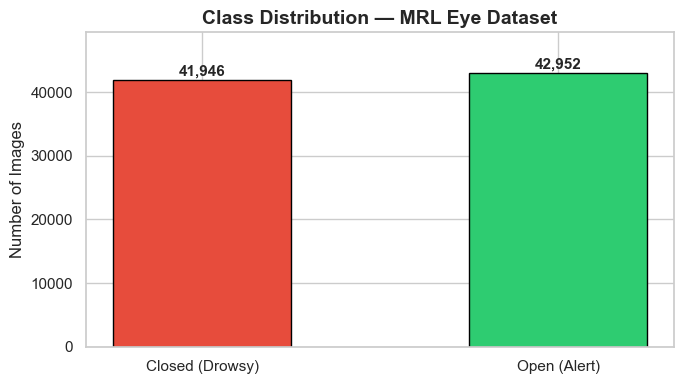


Imbalance ratio: 1.02x


In [6]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ['Closed (Drowsy)', 'Open (Alert)'],
    [closed_count, open_count],
    color=[COLORS[0], COLORS[1]],
    edgecolor='black', width=0.5
)
for bar, count in zip(bars, [closed_count, open_count]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Class Distribution — MRL Eye Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.set_ylim(0, max(closed_count, open_count) * 1.15)
plt.tight_layout()
plt.show()

# Imbalance ratio
ratio = max(closed_count, open_count) / min(closed_count, open_count)
print(f"\nImbalance ratio: {ratio:.2f}x")


In [ ]:
## 2. Sample Images — Closed vs Open Eyes


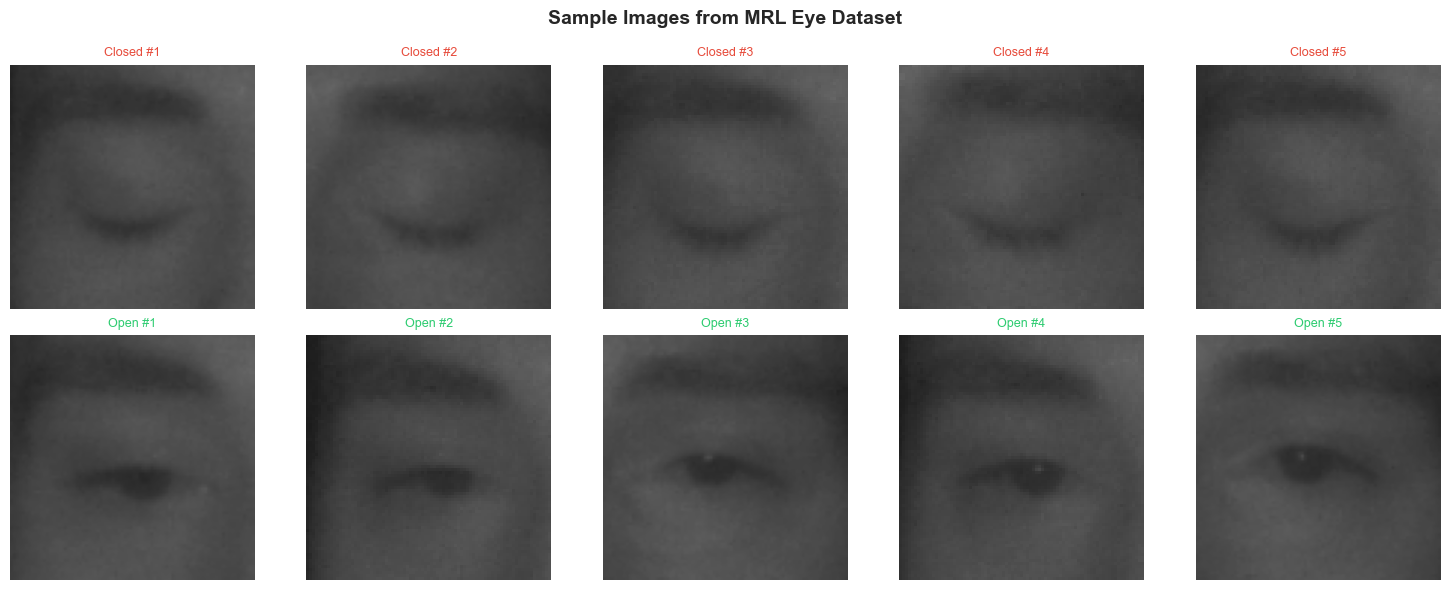

In [7]:
def load_sample_images(folder: Path, n: int = 5):
    files = sorted([f for f in folder.iterdir() if f.suffix.lower() in VALID_EXTS])[:n]
    imgs = []
    for f in files:
        img = cv2.imread(str(f))
        if img is not None:
            imgs.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    return imgs

closed_samples = load_sample_images(RAW_DIR / 'closed', n=5)
open_samples   = load_sample_images(RAW_DIR / 'open',   n=5)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from MRL Eye Dataset', fontsize=14, fontweight='bold')

for i, img in enumerate(closed_samples):
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Closed #{i+1}', color=COLORS[0], fontsize=9)
    axes[0, i].axis('off')

for i, img in enumerate(open_samples):
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Open #{i+1}', color=COLORS[1], fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Closed\n(Drowsy)', color=COLORS[0], fontsize=11, labelpad=10)
axes[1, 0].set_ylabel('Open\n(Alert)',   color=COLORS[1], fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()


## 3. Image Properties — Size, Channels, Pixel Statistics

Inspect the native resolution and pixel value distribution of raw images.


In [8]:
# Collect image sizes from a sample
def collect_sizes(folder: Path, sample=200):
    sizes = []
    files = [f for f in folder.iterdir() if f.suffix.lower() in VALID_EXTS]
    for f in files[:sample]:
        img = cv2.imread(str(f))
        if img is not None:
            sizes.append(img.shape[:2])  # (H, W)
    return sizes

closed_sizes = collect_sizes(RAW_DIR / 'closed')
open_sizes   = collect_sizes(RAW_DIR / 'open')

all_sizes = closed_sizes + open_sizes
heights = [s[0] for s in all_sizes]
widths  = [s[1] for s in all_sizes]

print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.1f}")
print(f"Width  — min: {min(widths)},  max: {max(widths)},  mean: {np.mean(widths):.1f}")
print(f"\nUnique sizes: {set(all_sizes)}")


Height — min: 69, max: 107, mean: 85.6
Width  — min: 69,  max: 107,  mean: 85.6

Unique sizes: {(98, 98), (84, 84), (107, 107), (103, 103), (80, 80), (89, 89), (75, 75), (76, 76), (85, 85), (94, 94), (72, 72), (81, 81), (90, 90), (99, 99), (86, 86), (77, 77), (95, 95), (104, 104), (91, 91), (100, 100), (96, 96), (105, 105), (82, 82), (73, 73), (101, 101), (78, 78), (87, 87), (69, 69), (106, 106), (97, 97), (83, 83), (74, 74), (92, 92), (93, 93), (79, 79), (102, 102), (88, 88)}


C:\Users\raka1005\AppData\Local\Temp\1\ipykernel_13876\1943167776.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


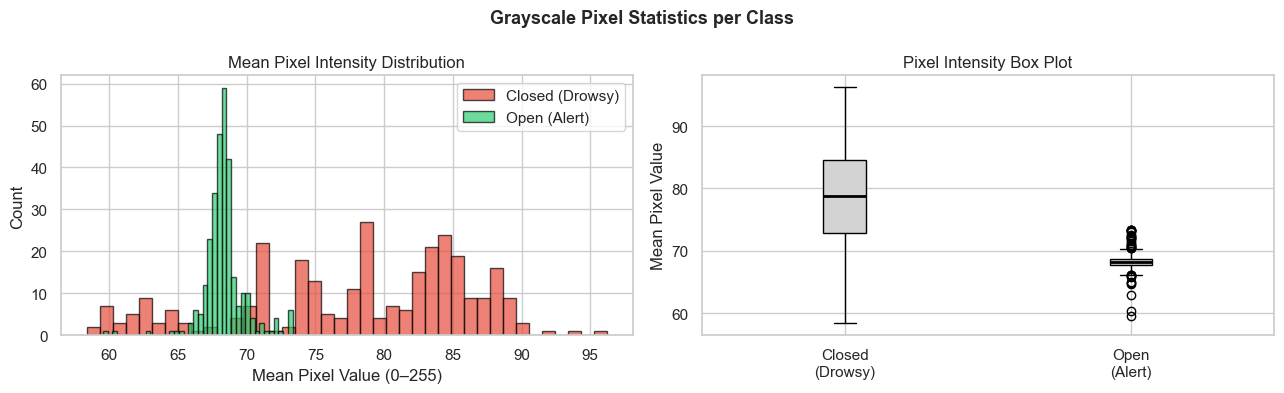

Closed mean pixel avg: 78.08
Open   mean pixel avg: 68.31


In [9]:
# Pixel intensity distribution per class (grayscale mean)
def pixel_stats(folder: Path, sample=300):
    means = []
    files = [f for f in folder.iterdir() if f.suffix.lower() in VALID_EXTS]
    for f in files[:sample]:
        img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            means.append(img.mean())
    return means

closed_means = pixel_stats(RAW_DIR / 'closed')
open_means   = pixel_stats(RAW_DIR / 'open')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(closed_means, bins=40, color=COLORS[0], alpha=0.7, label='Closed (Drowsy)', edgecolor='black')
axes[0].hist(open_means,   bins=40, color=COLORS[1], alpha=0.7, label='Open (Alert)',   edgecolor='black')
axes[0].set_title('Mean Pixel Intensity Distribution')
axes[0].set_xlabel('Mean Pixel Value (0–255)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
axes[1].boxplot(
    [closed_means, open_means],
    labels=['Closed\n(Drowsy)', 'Open\n(Alert)'],
    patch_artist=True,
    boxprops=dict(facecolor='lightgrey'),
    medianprops=dict(color='black', linewidth=2)
)
axes[1].set_title('Pixel Intensity Box Plot')
axes[1].set_ylabel('Mean Pixel Value')

plt.suptitle('Grayscale Pixel Statistics per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Closed mean pixel avg: {np.mean(closed_means):.2f}")
print(f"Open   mean pixel avg: {np.mean(open_means):.2f}")


## 4. Processed Dataset — NumPy Arrays

Inspect the preprocessed `.npy` arrays (64×64 RGB, normalized to [0,1]) used for training.


In [10]:
# Load processed arrays
X_train = np.load(PROCESSED_DIR / 'X_train.npy')
X_val   = np.load(PROCESSED_DIR / 'X_val.npy')
X_test  = np.load(PROCESSED_DIR / 'X_test.npy')
y_train = np.load(PROCESSED_DIR / 'y_train.npy')
y_val   = np.load(PROCESSED_DIR / 'y_val.npy')
y_test  = np.load(PROCESSED_DIR / 'y_test.npy')

print(f"{'Split':<10} {'X shape':<25} {'y shape':<15} {'Dtype'}")
print("-" * 65)
for name, X, y in [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]:
    print(f"{name:<10} {str(X.shape):<25} {str(y.shape):<15} {X.dtype}")

print(f"\nPixel range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Image size : {X_train.shape[1]}×{X_train.shape[2]} px, {X_train.shape[3]} channels")


Split      X shape                   y shape         Dtype
-----------------------------------------------------------------
Train      (59428, 64, 64, 3)        (59428,)        float32
Val        (12734, 64, 64, 3)        (12734,)        float32
Test       (12736, 64, 64, 3)        (12736,)        float32

Pixel range: [0.000, 1.000]
Image size : 64×64 px, 3 channels


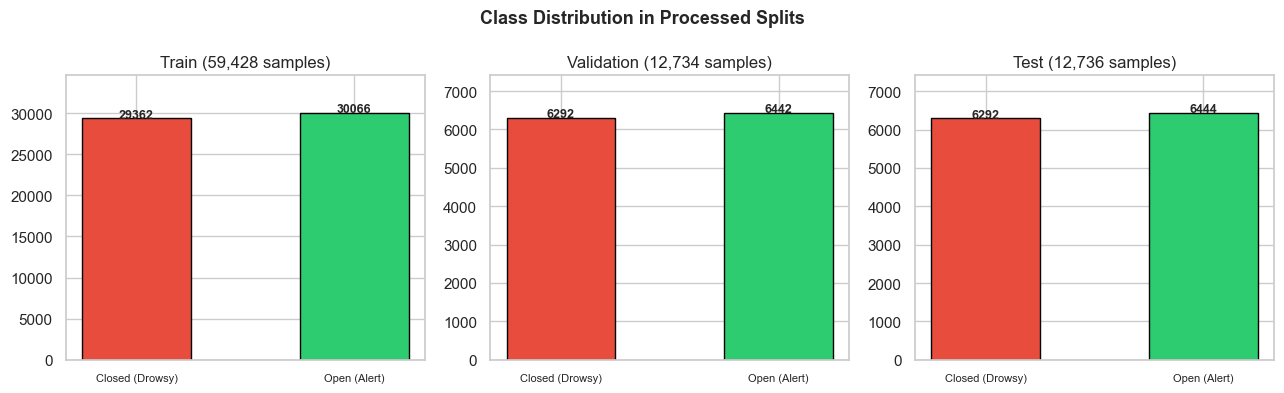

In [11]:
# Class distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Class Distribution in Processed Splits', fontsize=13, fontweight='bold')

for ax, (name, y) in zip(axes, [('Train', y_train), ('Validation', y_val), ('Test', y_test)]):
    counts = Counter(y.astype(int))
    labels = [CLASS_NAMES[k] for k in sorted(counts)]
    values = [counts[k] for k in sorted(counts)]
    bars = ax.bar(labels, values, color=[COLORS[0], COLORS[1]], edgecolor='black', width=0.5)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(v), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'{name} ({sum(values):,} samples)')
    ax.set_ylim(0, max(values) * 1.15)
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()


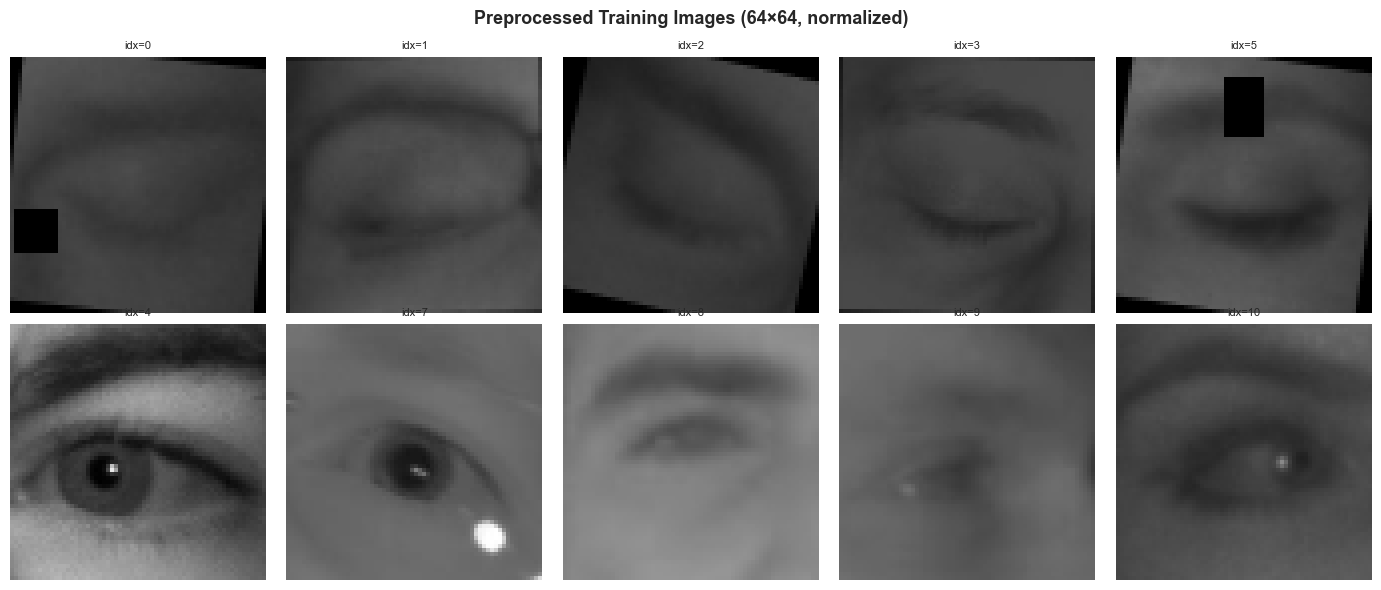

In [12]:
# Sample preprocessed images from training set
n_per_class = 5
fig, axes = plt.subplots(2, n_per_class, figsize=(14, 6))
fig.suptitle('Preprocessed Training Images (64×64, normalized)', fontsize=13, fontweight='bold')

for label, row in [(0, 0), (1, 1)]:
    idxs = np.where(y_train == label)[0][:n_per_class]
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(X_train[idx])
        axes[row, col].set_title(f'idx={idx}', fontsize=8)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(CLASS_NAMES[label], fontsize=10,
                            color=COLORS[label], labelpad=8)

plt.tight_layout()
plt.show()


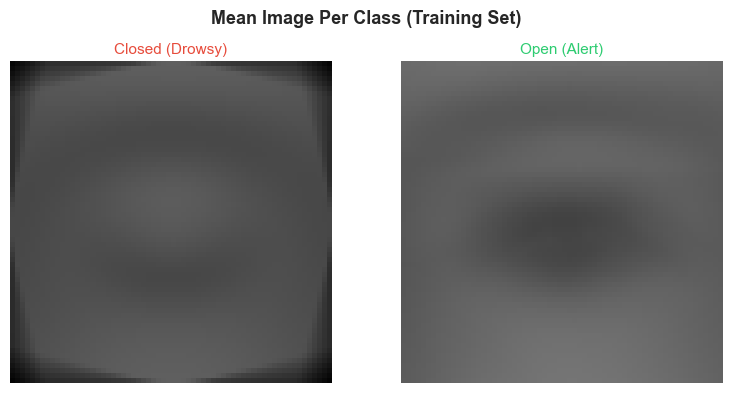

In [13]:
# Mean image per class (average face of each category)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle('Mean Image Per Class (Training Set)', fontsize=13, fontweight='bold')

for label in [0, 1]:
    mean_img = X_train[y_train == label].mean(axis=0)
    axes[label].imshow(mean_img)
    axes[label].set_title(CLASS_NAMES[label], color=COLORS[label], fontsize=11)
    axes[label].axis('off')

plt.tight_layout()
plt.show()


## Conclusion

Key findings from the EDA:

| Observation | Detail |
|---|---|
| **Dataset** | MRL Eye — CC0 public domain, safe for academic use |
| **Classes** | Binary: Closed (drowsy=0) / Open (alert=1) |
| **Image size** | Native varies; preprocessed to 64×64 RGB |
| **Pixel values** | Normalized to [0, 1] |
| **Class balance** | Check imbalance ratio above; augmentation applied to minority class |
| **Splits** | 70% train / 15% val / 15% test (stratified) |

**Next steps:** Model training in `01-training.ipynb`
